In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import LabelEncoder

In [76]:
data = pd.read_csv('bank-customers.csv')
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [77]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [78]:
x=data[['age','loan','nr.employed','subscribed']]
x

,age,loan,nr.employed,subscribed
0,56,no,5191.0,no
1,57,no,5191.0,no
2,37,no,5191.0,no
3,40,no,5191.0,no
4,56,yes,5191.0,no
...,...,...,...,...
41183,73,no,4963.6,yes
41184,46,no,4963.6,no
41185,56,no,4963.6,no
41186,44,no,4963.6,yes


In [79]:
from sklearn.decomposition import PCA

In [80]:
enc=LabelEncoder()

In [81]:
x['loan']= enc.fit_transform(x['loan'])
x['loan']

C:\Users\ALKODS\AppData\Local\Temp\ipykernel_5324\3819653415.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['loan']= enc.fit_transform(x['loan'])


0        0
1        0
2        0
3        0
4        2
        ..
41183    0
41184    0
41185    0
41186    0
41187    0
Name: loan, Length: 41188, dtype: int32

In [82]:
x['subscribed']=enc.fit_transform(x['subscribed'])
x['subscribed']

C:\Users\ALKODS\AppData\Local\Temp\ipykernel_5324\2660483860.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['subscribed']=enc.fit_transform(x['subscribed'])


0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: subscribed, Length: 41188, dtype: int32

In [83]:
x

,age,loan,nr.employed,subscribed
0,56,0,5191.0,0
1,57,0,5191.0,0
2,37,0,5191.0,0
3,40,0,5191.0,0
4,56,2,5191.0,0
...,...,...,...,...
41183,73,0,4963.6,1
41184,46,0,4963.6,0
41185,56,0,4963.6,0
41186,44,0,4963.6,1


In [84]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)
X_pca=pd.DataFrame(X_pca,columns=['x','y'])
X_pca

,x,y
0,23.922429,16.038559
1,23.919818,17.038555
2,23.972036,-2.961369
3,23.964203,0.038620
4,23.922507,16.037541
...,...,...
41183,-203.522460,32.445240
41184,-203.450413,5.444615
41185,-203.476522,15.444576
41186,-203.446743,3.445350


In [85]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X_pca)

In [86]:
x_scaled=pd.DataFrame(x_scaled,columns=['x','y'])
x_scaled_copy=x_scaled.copy()
x_scaled

,x,y
0,0.331102,1.539290
1,0.331066,1.635263
2,0.331788,-0.284215
3,0.331680,0.003707
4,0.331103,1.539192
...,...,...
41183,-2.816882,3.113909
41184,-2.815885,0.522543
41185,-2.816246,1.482282
41186,-2.815834,0.330665


In [87]:
kmeans=KMeans()

In [88]:
wcss =[]

# Create all possible cluster solutions with a loop
# We have chosen to get solutions from 1 to 9 clusters; you can ammend that if you wish
for i in range(1,10):
    # Clsuter solution with i clusters
    kmeans = KMeans(i)
    # Fit the STANDARDIZED data
    kmeans.fit(x_scaled)
    # Append the WCSS for the iteration
    wcss.append(kmeans.inertia_)
    
# Check the result
wcss

[82376.00000000074,
 54035.65266324632,
 29676.631171678564,
 18523.463813098824,
 15509.757016179396,
 12425.396270661353,
 9719.979644053725,
 8632.547910789872,
 7216.793378751939]

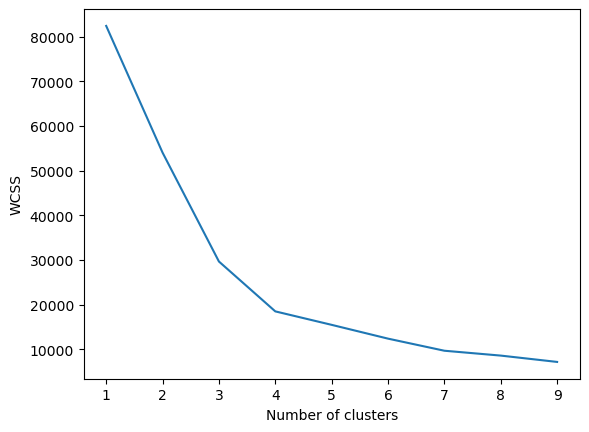

In [89]:
plt.plot(range(1,10),wcss)

# Name your axes
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [90]:
kmeans=KMeans(7)

In [91]:
x_scaled['cluster']=kmeans.fit_predict(x_scaled)
x_copy=x.copy()
x_copy['cluster']=kmeans.fit_predict(x)


In [92]:
x_scaled.head()

,x,y,cluster
0,0.331102,1.539290,4
1,0.331066,1.635263,4
2,0.331788,-0.284215,1
3,0.331680,0.003707,1
4,0.331103,1.539192,4


In [93]:
x.head()

,age,loan,nr.employed,subscribed
0,56,0,5191.0,0
1,57,0,5191.0,0
2,37,0,5191.0,0
3,40,0,5191.0,0
4,56,2,5191.0,0


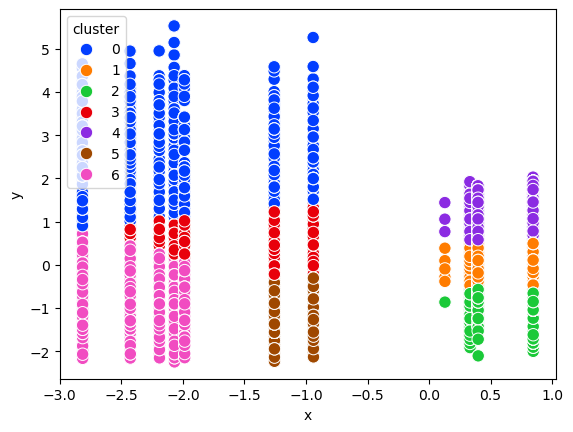

In [94]:
sns.scatterplot(data=x_scaled , x='x',y='y',hue='cluster',s=80,palette="bright")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

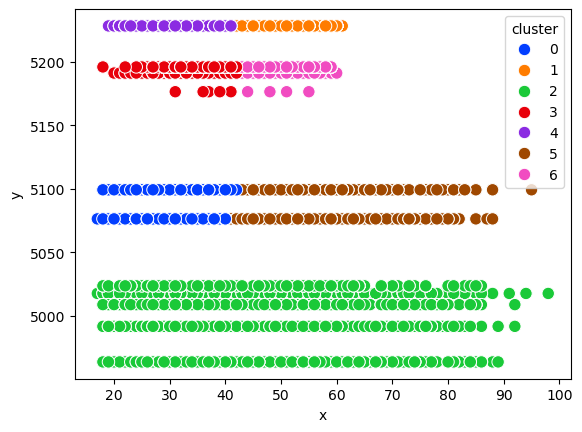

In [95]:
sns.scatterplot(data=x_copy , x='age',y='nr.employed',hue='cluster',s=80,palette="bright")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [96]:
from sklearn.metrics import silhouette_score

In [97]:
print(silhouette_score(x,kmeans.fit_predict(x)))

0.6700541283893112


In [99]:
print(silhouette_score(x_scaled_copy,kmeans.fit_predict(x_scaled_copy)))

0.4772050933622296


In [100]:
import scipy.cluster.hierarchy as sch

In [ ]:
plt.figure(figsize=(20,10))
dendrogram = sch.dendrogram(sch.linkage(x, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('x')
plt.ylabel('Euclidean distances')
plt.show()